In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes
def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0, [], [])

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)  # Store IMI as a list of timestamps
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Load the metafile and process the data
metafile = "..\\src\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\src\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

        # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],       # IPI for grain phase
        mice[key]["grain_imi"]        # IMI for grain phase
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],          # IPI for PR phase
        mice[key]["pr_imi"]           # IMI for PR phase
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],          # IPI for NR phase
        mice[key]["nr_imi"]           # IMI for NR phase
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])
    print("  IPI for Grain phase:", mice[key]["grain_ipi"])
    print("  IMI for Grain phase:", mice[key]["grain_imi"])
    print("  IPI for PR phase:", mice[key]["pr_ipi"])
    print("  IMI for PR phase:", mice[key]["pr_imi"])
    print("  IPI for NR phase:", mice[key]["nr_ipi"])
    print("  IMI for NR phase:", mice[key]["nr_imi"])



Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [43, 25, 23, 35, 28, 31, 24, 24, 31, 14, 9, 18, 18, 15, 13, 9, 6]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 1, 1, 2, 3, 3, 1, 2, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 3, 3, 2, 1, 2, 0, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 0, 0, 3], [0, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 3, 3, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 4, 2, 3, 2, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 1.0133227626203154
  Mega Meals Size: 7.27810650887574
  IPI for Grain phase: [2.77777778e-04 5.55555556e-04 2.77777778e-04 2.77777778e-04
 7.13

6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
['black']


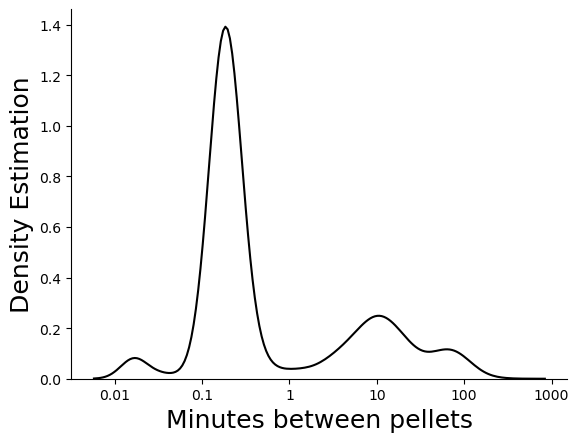

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns

def interpellet_interval_plot(data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    Parameters
    ----------
    FEDs : list of FED3_File objects
        FED3 files (loaded by load.FED3_File)
    kde : bool
        Whether or not to include kernel density estimation, which plots
        probability density (rather than count) and includes a fit line (see
        seaborn.distplot)
    **kwargs :
        ax : matplotlib.axes.Axes
            Axes to plot on, a new Figure and Axes are
            created if not passed
        date_filter : array
            A two-element array of datetimes (start, end) used to filter
            the data
        **kwargs also allows FED3 Viz to pass all settings to all functions.
    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    if ax == []:
        f, ax = plt.subplots()

    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    print(colors)

    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):

        y = tp.flatten_list(group)
        y = [np.log10(val*60) for val in y if val > 0]
            
        sns.kdeplot(y, ax=ax,
                    color=colors[idx],
                    fill=fill,
                    label=labels[idx],
                    linestyle=linestyle)

    ax.set_ylabel('Density Estimation',fontsize = 18)
    ax.set_xlabel('Minutes between pellets',fontsize = 18)

    ax.set_xticks(range(-2,4))
    ax.set_xticklabels([10**num for num in range(-2,4)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IPIs_m_nrpr_gr = get_data_fields(mice, ["grain_ipi"], nrpr_male_selector)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_male_selector)

IPIs_m_prnr_pr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)
IPIs_m_prnr_nr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)

f, ax = plt.subplots()

interpellet_interval_plot([IPIs_m_nrpr_nr],
                           colors=["black"],
                           linestyle="-",
                           ax=ax)

# interpellet_interval_plot([IPIs_m_nrpr_nr],
#                            colors=["grey"],
#                            linestyle="--",
#                            ax=ax)


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
['green']
['grey']


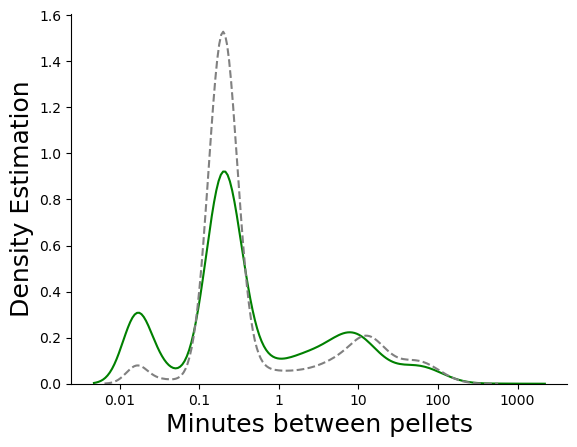

In [4]:
def interpellet_interval_plot(data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    Parameters
    ----------
    FEDs : list of FED3_File objects
        FED3 files (loaded by load.FED3_File)
    kde : bool
        Whether or not to include kernel density estimation, which plots
        probability density (rather than count) and includes a fit line (see
        seaborn.distplot)
    **kwargs :
        ax : matplotlib.axes.Axes
            Axes to plot on, a new Figure and Axes are
            created if not passed
        date_filter : array
            A two-element array of datetimes (start, end) used to filter
            the data
        **kwargs also allows FED3 Viz to pass all settings to all functions.
    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    if ax == []:
        f, ax = plt.subplots()

    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    print(colors)

    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):

        y = tp.flatten_list(group)
        y = [np.log10(val*60) for val in y if val > 0]
            
        sns.kdeplot(y, ax=ax,
                    color=colors[idx],
                    fill=fill,
                    label=labels[idx],
                    linestyle=linestyle)

    ax.set_ylabel('Density Estimation',fontsize = 18)
    ax.set_xlabel('Minutes between pellets',fontsize = 18)

    ax.set_xticks(range(-2,4))
    ax.set_xticklabels([10**num for num in range(-2,4)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}

IPIs_m_nrpr_gr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], prnr_male_selector)

IPIs_m_prnr_pr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)
IPIs_m_prnr_nr = get_data_fields(mice, ["grain_ipi"], prnr_male_selector)

f, ax = plt.subplots()

interpellet_interval_plot([IPIs_m_nrpr_gr],
                           colors=["green"],
                           linestyle="-",
                           ax=ax)

interpellet_interval_plot([IPIs_m_nrpr_nr],
                           colors=["grey"],
                           linestyle="--",
                           ax=ax)


# <span style="color: #FF6B6B;">plot below used in the sup file</span>

6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
6 items in output dictionary


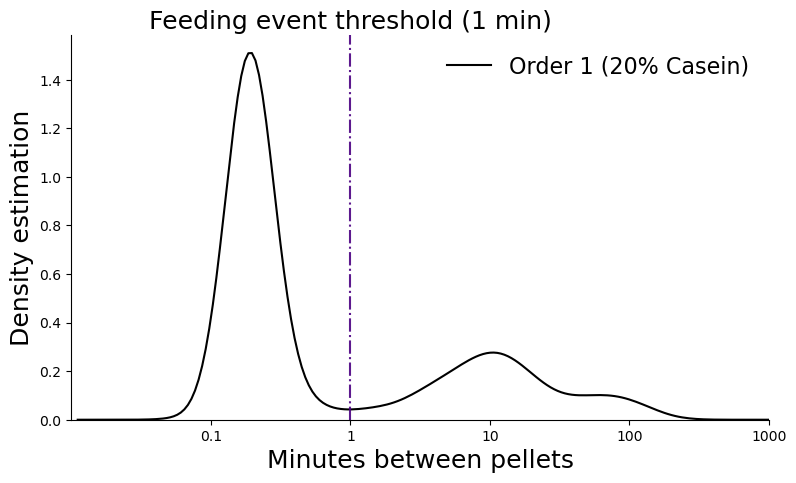

In [5]:
def interpellet_interval_plot(data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    
    Parameters
    ----------
    data : list of lists
        Interpellet intervals (or lists of intervals).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If not passed, a new Figure and Axes are created.
    colors : list of str
        Colors for each dataset.
    fill : bool
        Whether to fill the area under the KDE curve.
    labels : list of str
        Labels for each dataset.
    linestyle : str
        Line style for the KDE curves.
    **kwargs :
        Additional keyword arguments (unused here, but allows flexibility).
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        Matplotlib Figure object (if needed).
    """

    # Create new figure/axes if none provided
    if ax == []:
        f, ax = plt.subplots()

    # Ensure we have a color and label for each dataset
    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):
        # Flatten lists if needed
        y_raw = tp.flatten_list(group)
        
        # 1) Keep intervals >= 0.01 minutes (0.6 s)
        y_filtered = [val for val in y_raw if (val > 0) and (val * 60 >= 0.05)]
        
        # 2) Convert from hours to minutes, then take log10
        y_log = [np.log10(val * 60) for val in y_filtered]
        
        # 3) Plot KDE, allowing the curve to start around -2 (0.01 min)
        sns.kdeplot(
            y_log,
            ax=ax,
            color=colors[idx],
            fill=fill if idx == 0 else False,  # Only fill for the first dataset
            label=labels[idx],
            linestyle=linestyle,
            clip=(-4, None),   # Don't extend below log10(0.01) = -2
            cut=5, # No extra smoothing beyond data range
                        # alpha=1 if fill and colors[idx] == "dodgerblue" else 0.1  # Full opacity for black fill             
        )

    # Axis labels
    ax.set_ylabel("Density estimation", fontsize=18)
    ax.set_xlabel("Minutes between pellets", fontsize=18)

    # 4) Show data from 0.01 min (10^-2) up to 1000 min (10^3),
    #    but do NOT label 10^-2 as a major tick.
    ax.set_xlim([-2, 3])
    
    # Major ticks: from -1 => 0.1 min, up to 10^3 => 1000 min
    ax.set_xticks(range(-1, 4))  # [-1, 0, 1, 2, 3]
    ax.set_xticklabels([10**num for num in range(-1, 4)])  # [0.1, 1, 10, 100, 1000]

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# Selectors for:
#   - Order 1 M/F = NR Diet
nrpr_male_selector   = {"order": 1, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}

#   - Order 2 M/F = PR Diet
prpr_male_selector   = {"order": 2, "sex": "M"}
prpr_female_selector = {"order": 2, "sex": "F"}

# Fetch data for M/F mice under Order 1 (nr_ipi)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_male_selector)
IPIs_f_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_female_selector)
IPIs_nrpr_aggregated = IPIs_m_nrpr_nr + IPIs_f_nrpr_nr

# Fetch data for M/F mice under Order 2 (pr_ipi)
IPIs_m_prpr_pr = get_data_fields(mice, ["pr_ipi"], prpr_male_selector)
IPIs_f_prpr_pr = get_data_fields(mice, ["pr_ipi"], prpr_female_selector)
IPIs_prpr_aggregated = IPIs_m_prpr_pr + IPIs_f_prpr_pr

# Create a larger figure and axes
f, ax = plt.subplots(figsize=(9, 5))

# Plot Order 1 (NR) M+F
interpellet_interval_plot(
    [IPIs_nrpr_aggregated],
    colors=["black"],  # Black color for Order 1
    linestyle="-",
    labels=["Order 1 (20% Casein)"],  # Label for Order 1
    ax=ax, 
    fill=False  # Fill the KDE curve for Order 1
)

# # Overlay Order 2 (PR) M+F without fill
# interpellet_interval_plot(
#     [IPIs_prpr_aggregated],
#     colors=["dodgerblue"],  # Blue color for Order 2
#     linestyle="-",
#     labels=["Order 2 (5% Casein)"],  # Label for Order 2
#     ax=ax,
#     fill=False  # Do not fill the KDE curve for Order 2
# )

# Add vertical line and annotation
ax.axvline(0, linestyle="-.", color="indigo", alpha=0.9)
ax.text(0, 1.61, "Feeding event threshold (1 min)", ha="center", fontsize=18)

# Customize legend
legend = ax.legend(fontsize=16, frameon=False)
plt.setp(legend.get_texts(), color="black")  # Ensure legend text is visible

# plt.savefig("../plots/NEW_MEAL_PLOTS/KDE_CURVE_01.png", bbox_inches='tight', dpi=220)

plt.show()







# <font color = "green"> Just in case we need to visualize some other data </font>


6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
6 items in output dictionary


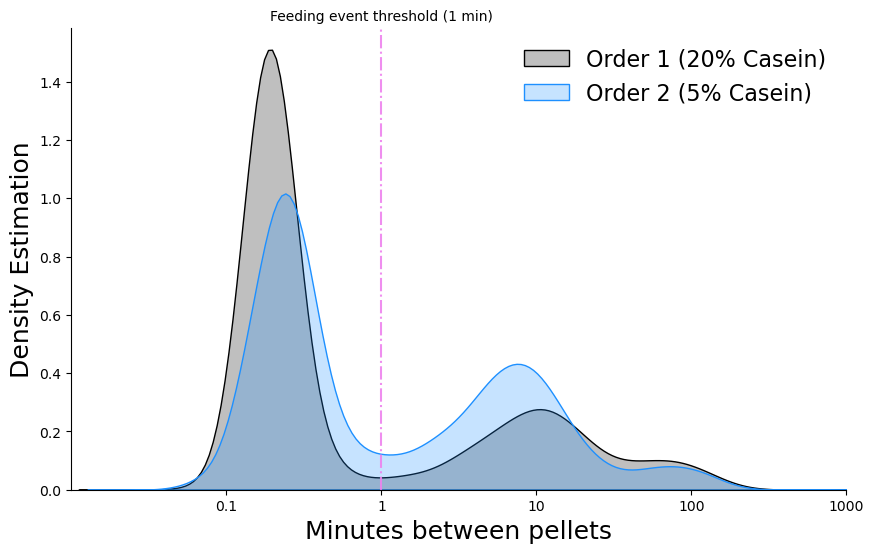

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def interpellet_interval_plot(data, ax=[], colors=[], fill=True, labels=[], linestyle="-", **kwargs):
    """
    FED3 Viz: Plot a histogram of interpellet intervals for multiple devices.
    
    Parameters
    ----------
    data : list of lists
        Interpellet intervals (or lists of intervals).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If not passed, a new Figure and Axes are created.
    colors : list of str
        Colors for each dataset.
    fill : bool
        Whether to fill the area under the KDE curve.
    labels : list of str
        Labels for each dataset.
    linestyle : str
        Line style for the KDE curves.
    **kwargs :
        Additional keyword arguments (unused here, but allows flexibility).
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        Matplotlib Figure object (if needed).
    """

    # Create new figure/axes if none provided
    if ax == []:
        f, ax = plt.subplots()

    # Ensure we have a color and label for each dataset
    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    for idx, group in enumerate(data):
        # Flatten lists if needed
        y_raw = tp.flatten_list(group)
        
        # 1) Keep intervals >= 0.01 minutes (0.6 s)
        y_filtered = [val for val in y_raw if (val > 0) and (val * 60 >= 0.05)]
        
        # 2) Convert from hours to minutes, then take log10
        y_log = [np.log10(val * 60) for val in y_filtered]
        
        # 3) Plot KDE, allowing the curve to start around -2 (0.01 min)
        sns.kdeplot(
            y_log,
            ax=ax,
            color=colors[idx],
            fill=fill,
            label=labels[idx],
            linestyle=linestyle,
            clip=(-4, None),   # Don't extend below log10(0.01) = -2
            cut=5            # No extra smoothing beyond data range
        )

    # Axis labels
    ax.set_ylabel("Density Estimation", fontsize=18)
    ax.set_xlabel("Minutes between pellets", fontsize=18)

    # 4) Show data from 0.01 min (10^-2) up to 1000 min (10^3),
    #    but do NOT label 10^-2 as a major tick.
    ax.set_xlim([-2, 3])
    
    # Major ticks: from -1 => 0.1 min, up to 10^3 => 1000 min
    ax.set_xticks(range(-1, 4))  # [-1, 0, 1, 2, 3]
    ax.set_xticklabels([10**num for num in range(-1, 4)])  # [0.1, 1, 10, 100, 1000]

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)




# Selectors for:
#   - Order 1 M/F = NR Diet
nrpr_male_selector   = {"order": 1, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}

#   - Order 2 M/F = PR Diet
prpr_male_selector   = {"order": 2, "sex": "M"}
prpr_female_selector = {"order": 2, "sex": "F"}

# Fetch data for M/F mice under Order 1 (nr_ipi)
IPIs_m_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_male_selector)
IPIs_f_nrpr_nr = get_data_fields(mice, ["nr_ipi"], nrpr_female_selector)
IPIs_nrpr_aggregated = IPIs_m_nrpr_nr + IPIs_f_nrpr_nr

# Fetch data for M/F mice under Order 2 (pr_ipi)
IPIs_m_prpr_pr = get_data_fields(mice, ["pr_ipi"], prpr_male_selector)
IPIs_f_prpr_pr = get_data_fields(mice, ["pr_ipi"], prpr_female_selector)
IPIs_prpr_aggregated = IPIs_m_prpr_pr + IPIs_f_prpr_pr

# Create a larger figure and axes
f, ax = plt.subplots(figsize=(10, 6))

# Plot Order 1 (NR) M+F
interpellet_interval_plot(
    [IPIs_nrpr_aggregated],
    colors=["black"],
    linestyle="-",
    labels=["Order 1 (20% Casein)"],
    ax=ax, fill=True
)

# Overlay Order 2 (PR) M+F
interpellet_interval_plot(
    [IPIs_prpr_aggregated],
    colors=["dodgerblue"],
    linestyle="-",
    labels=["Order 2 (5% Casein)"],
    ax=ax
)
ax.axvline(0, linestyle="-.", color="violet", alpha=0.9)
ax.text(0,1.61, "Feeding event threshold (1 min)", ha="center")
# Make legend box invisible
ax.legend(fontsize=16, frameon=False)
plt.show()




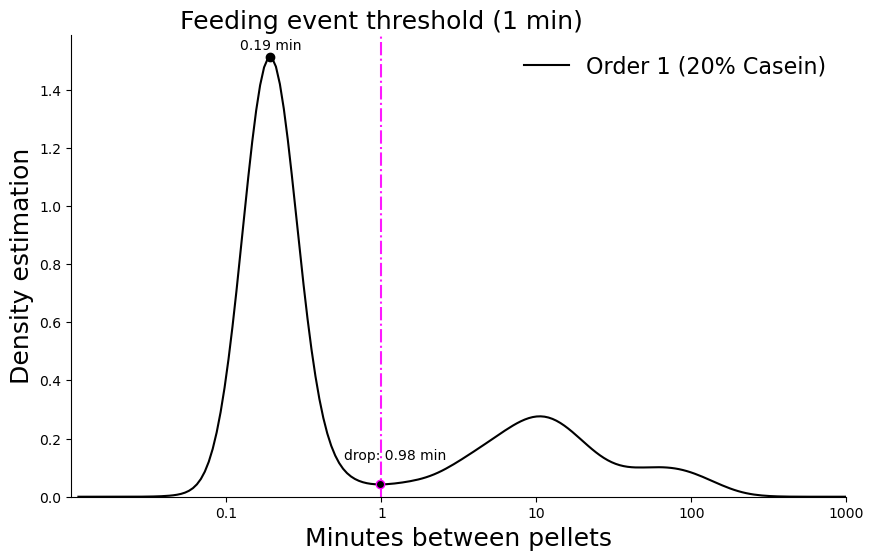

Peaks and dips for Order 1 (NR): [((np.float64(-0.7169870670422923), np.float64(1.5128325808097094)), (np.float64(-0.00859951490768096), np.float64(0.042385046985801325)))]


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde


def calculate_kde_peak_and_dip(y_log):
    """Calculate the peak (x, y) and first dip (x, y) after the peak of the KDE curve."""
    kde = gaussian_kde(y_log)
    x_data = np.linspace(min(y_log), max(y_log), 1000)  # Generate x values
    y_data = kde(x_data)  # Evaluate the KDE for the x values

    # Find the peak
    peak_idx = np.argmax(y_data)
    peak_x = x_data[peak_idx]
    peak_y = y_data[peak_idx]

    # Find the first dip (minimum) after the peak
    dip_x, dip_y = None, None
    for i in range(peak_idx + 1, len(y_data) - 1):
        if y_data[i] < y_data[i - 1] and y_data[i] < y_data[i + 1]:
            dip_x = x_data[i]
            dip_y = y_data[i]
            break

    return (peak_x, peak_y), (dip_x, dip_y)


def interpellet_interval_plot_with_peak_and_dip(
    data, ax=[], colors=[], fill=False, labels=[], linestyle="-", **kwargs
):
    """Plot inter-pellet intervals with peak and dip calculation."""
    if ax == []:
        f, ax = plt.subplots()

    if len(colors) != len(data):
        colors = ["grey"] * len(data)
    if len(labels) != len(data):
        labels = [str(n) for n in range(len(data))]

    peaks_and_dips = []  # Store peaks and dips for each dataset

    for idx, group in enumerate(data):
        y_raw = tp.flatten_list(group)
        y_filtered = [val for val in y_raw if (val > 0) and (val * 60 >= 0.05)]
        y_log = [np.log10(val * 60) for val in y_filtered]

        # Calculate peak and dip for this dataset
        peak, dip = calculate_kde_peak_and_dip(y_log)
        peaks_and_dips.append((peak, dip))

        sns.kdeplot(
            y_log,
            ax=ax,
            color=colors[idx],
            fill=fill,
            label=f"{labels[idx]}",
            linestyle=linestyle,
            clip=(-4, None),
            cut=5,
        )

        # Annotate the peak on the plot
        ax.scatter(peak[0], peak[1], color=colors[idx], edgecolor="black", zorder=10)
        ax.text(
            peak[0],
            peak[1] * 1.016,  # Slightly above the peak
            f"{10**peak[0]:.2f} min",
            ha="center",
            fontsize=10,
            color=colors[idx],
        )

        # Annotate the first dip on the plot
        if dip[0] is not None:
            ax.scatter(dip[0], dip[1], color=colors[idx], edgecolor="magenta", zorder=10)
            ax.text(
                dip[0] + 0.1,  # Move slightly to the right
                dip[1] * 3,  # Slightly below the dip
                f"drop: {10**dip[0]:.2f} min",
                ha="center",
                fontsize=10,
                color="black",
            )

    ax.set_ylabel("Density estimation", fontsize=18)
    ax.set_xlabel("Minutes between pellets", fontsize=18)
    ax.set_xlim([-2, 3])
    ax.set_xticks(range(-1, 4))
    ax.set_xticklabels([10**num for num in range(-1, 4)])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return peaks_and_dips


# Main plotting code
f, ax = plt.subplots(figsize=(10, 6))

# Plot Order 1 (NR) M+F with peak and dip calculation
peaks_and_dips_order1 = interpellet_interval_plot_with_peak_and_dip(
    [IPIs_nrpr_aggregated],
    colors=["black"],
    linestyle="-",
    labels=["Order 1 (20% Casein)"],
    ax=ax,
    fill=False,
)

# Overlay Order 2 (PR) M+F with peak and dip calculation (uncomment if needed)
# peaks_and_dips_order2 = interpellet_interval_plot_with_peak_and_dip(
#     [IPIs_prpr_aggregated],
#     colors=["dodgerblue"],
#     linestyle="-",
#     labels=["Order 2 (5% Casein)"],
#     ax=ax,
#     fill=False,
# )

# Add vertical line and annotation
ax.axvline(0, linestyle="-.", color="magenta", alpha=0.9)
ax.text(0, 1.61, "Feeding event threshold (1 min)", ha="center", fontsize=18)

# Customize legend
legend = ax.legend(fontsize=16, frameon=False)
plt.setp(legend.get_texts(), color="black")

#plt.savefig("../plots/NEW_MEAL_PLOTS/KDE_CURVE_WITH_PEAK_AND_DIP.png", bbox_inches="tight", dpi=220)
plt.show()

# Print peaks and dips
print("Peaks and dips for Order 1 (NR):", peaks_and_dips_order1)

# print("Peaks and dips for Order 2 (PR):", peaks_and_dips_order2)
